In [42]:
# load the K562 model + all seqs/annotations EXACTLY as swap_experiment.ipynb: single annotation source
# situate/edits.csv keyed SEAM:K562:{name}:foreground_scaled (spans var-region [0,200) -> +ADAPTER).
import sys, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt, h5py
from pathlib import Path
sys.path.insert(0, "/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/"
                   "Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src")
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle
from alphagenome_encoder_ft import EncoderMPRAModel

ADAPTER = 15                                        # var region = insert[15:215]
LIB = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/mutagenesis_lib")
FG = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/foregrounds")

CKPT = "/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt"
model = EncoderMPRAModel.from_checkpoint(CKPT, device="cuda").eval()
cfg = torch.load(CKPT, map_location="cpu", weights_only=False)["construct_config"]
suffix = one_hot_encode(cfg["promoter_seq"] + cfg["barcode_seq"]).float()   # (4,51) promoter+barcode

@torch.no_grad()
def score(ohe):                                     # (B,4,230) -> (B,) K562 pred
    out = []
    for k in range(0, len(ohe), 512):
        b = ohe[k:k + 512]
        x = torch.cat([b, suffix.expand(len(b), -1, -1)], 2)
        out.append(model(x.transpose(1, 2).cuda()).cpu().numpy())
    return np.concatenate(out)

# high = 3 designed peaks; WT strings from mutagenesis_lib h5
peaks = {0: "peak26256", 1: "peak84030", 2: "peak27535_Reversed"}
seq_str, all_names = {}, list(peaks.values())
for i, peak in peaks.items():
    with h5py.File(LIB / f"{peak}.h5") as f:
        seq_str[i] = f.attrs["wt_seq_str"]          # 230bp WT insert string
high = list(peaks)

# annotations: single source situate/edits.csv, keyed by SEAM:K562:{name}:foreground_scaled
sit = pd.read_csv("/grid/koo/home/pmantill/projects/situate/edits.csv")
spans = {k: [(int(s) + ADAPTER, int(e) + ADAPTER) for s, e in zip(g.start, g.end)]
         for k, g in sit.groupby("sequence_name")}
mot = {i: spans.get(f"SEAM:K562:{peaks[i]}:foreground_scaled", []) for i in high}

# low = repressing reps (WT from jointlib900); neutral = neutral_* (WT from K562 test set)
libj = pd.read_csv("/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConSwap_mpra/"
                   "SEAM_jointlib900/libraries/jointlib900_library.csv")   # csv avoids the pickle pandas-version clash
libj = libj[libj.cell_type == "K562"].set_index("seq_idx")
_mp = pd.read_csv("/grid/koo/home/pmantill/projects/SEAM_validate/data/mpra/K562_averaged.tsv", sep="\t")
seqmap = dict(zip(_mp.seq_id.astype(str).str.rstrip(":"), _mp.seq))
low, neutral = [], []
for name in sorted(d.name for d in FG.iterdir() if d.name.startswith("rep_")):
    key = f"SEAM:K562:{name}:foreground_scaled"
    if not spans.get(key):
        continue
    i = len(all_names); seq_str[i] = libj.loc[int(name[len("rep_"):]), "sequence"]
    mot[i] = spans[key]; all_names.append(name); low.append(i)
for name in sorted(d.name for d in FG.iterdir() if d.name.startswith("neutral_")):
    key = f"SEAM:K562:{name}:foreground_scaled"
    if not spans.get(key):
        continue
    i = len(all_names); seq_str[i] = seqmap[name[len("neutral_"):].rstrip(":")]
    mot[i] = spans[key]; all_names.append(name); neutral.append(i)
print(f"{len(high)} high, {len(low)} low, {len(neutral)} neutral")


3 high, 10 low, 10 neutral


In [43]:
# Core: knock the donor's WT motifs into each context scaffold `bg` (M,4,230), then KI each dinucleotide
# TYPE (AA, AT, ... 16) back at ALL its native WT context positions at once and re-score.
#   bg = donor's own dinuc-shuffle          -> baseline is the context KO (box = N shuffle reps)
#   bg = motif-KO'd neutral / low scaffolds -> baseline == swap_experiment's swap[donor][target] (motifs only)
N = 30
dinucs = [a + b for a in "ACGT" for b in "ACGT"]

def ko_context(i, n=N):                                                 # neutralize a scaffold's OWN motifs (== swap_experiment.context)
    wt = one_hot_encode(seq_str[i]).float()
    shuf = dinucleotide_shuffle(wt.unsqueeze(0), n=n, random_state=1)[0]   # (n,4,230), rs=1 matches swap notebook
    ctx = wt.unsqueeze(0).repeat(n, 1, 1).clone()
    for s, e in mot[i]:
        ctx[:, :, s:e] = shuf[:, :, s:e]
    return ctx

def dinuc_ki(donor, bg, reps=None):
    # reps set (neutral/low): bg = n_ctx contexts x reps shuffles -> average the reps so each box point = one context
    agg = (lambda p: p.reshape(-1, reps).mean(1)) if reps else (lambda p: p)
    dwt = one_hot_encode(seq_str[donor]).float()                        # (4,230)
    dseq = seq_str[donor]
    m_any = np.zeros(230, bool)
    for s, e in mot[donor]:
        m_any[s:e] = True
    base = bg.clone(); base[:, :, m_any] = dwt[:, m_any]                # donor motifs into every scaffold
    p_base = agg(score(base))
    p_ki, counts = {}, {}
    for d in dinucs:
        mask = np.zeros(230, bool)
        for i in range(ADAPTER, ADAPTER + 200 - 1):
            if dseq[i:i + 2] == d and not m_any[i:i + 2].any():         # context positions only
                mask[i:i + 2] = True; counts[d] = counts.get(d, 0) + 1
        if mask.any():
            x = base.clone(); x[:, :, mask] = dwt[:, mask]              # restore all instances of this dinuc
            p_ki[d] = agg(score(x))
    return m_any, p_base, p_ki, counts

# MAIN: for each high seq, scaffold = its own dinuc-shuffle -> context KO (== swap carrier), then dinuc KI
main = {}
for donor in high:
    dwt = one_hot_encode(seq_str[donor]).float()
    shuf = dinucleotide_shuffle(dwt.unsqueeze(0), n=N, random_state=0)[0]         # (N,4,230)
    m_any, p_ctxko, p_ki, counts = dinuc_ki(donor, shuf)
    motko = dwt.repeat(N, 1, 1).clone(); motko[:, :, m_any] = shuf[:, :, m_any]   # motifs shuffled, context WT
    main[donor] = dict(wt=float(score(dwt.unsqueeze(0))[0]), motko=score(motko),
                       ctxko=p_ctxko, ki=p_ki, counts=counts)

# NEUTRAL / LOW: high motifs in each motif-KO'd foreign context; average the N reps -> one point per context
neut_bg = torch.cat([ko_context(i) for i in neutral])                   # (n_neutral*N,4,230), context-major
low_bg = torch.cat([ko_context(i) for i in low])
neut_wt = float(score(torch.stack([one_hot_encode(seq_str[i]).float() for i in neutral])).mean())
low_wt = float(score(torch.stack([one_hot_encode(seq_str[i]).float() for i in low])).mean())
neut, lowc = {}, {}
for donor in high:
    _, pb, pk, c = dinuc_ki(donor, neut_bg, reps=N); neut[donor] = dict(wt=main[donor]["wt"], base=pb, ki=pk, counts=c)
    _, pb, pk, c = dinuc_ki(donor, low_bg,  reps=N); lowc[donor] = dict(wt=main[donor]["wt"], base=pb, ki=pk, counts=c)

# one shared pred scale across all three experiments and all seqs
allv = [main[d]["wt"] for d in high] + [neut_wt, low_wt]
for res in (main, neut, lowc):
    for r in res.values():
        allv += [float(v.min()) for v in r["ki"].values()] + [float(v.max()) for v in r["ki"].values()]
        allv += [float(r[k].min()) for k in ("motko", "ctxko", "base") if k in r]
        allv += [float(r[k].max()) for k in ("motko", "ctxko", "base") if k in r]
pad = 0.05 * (max(allv) - min(allv))
YLIM = (min(allv) - pad, max(allv) + pad)

for donor in high:
    r = main[donor]
    print(f"{all_names[donor]}: WT={r['wt']:.2f}  motif KO={r['motko'].mean():.2f}  context KO={r['ctxko'].mean():.2f}"
          f"  high->low={lowc[donor]['base'].mean():.2f}  high->neutral={neut[donor]['base'].mean():.2f}")


peak26256: WT=1.73  motif KO=-0.42  context KO=1.09  high->low=0.79  high->neutral=1.02
peak84030: WT=1.79  motif KO=-0.04  context KO=0.89  high->low=0.89  high->neutral=1.10
peak27535_Reversed: WT=1.77  motif KO=-0.52  context KO=0.87  high->low=0.99  high->neutral=1.14


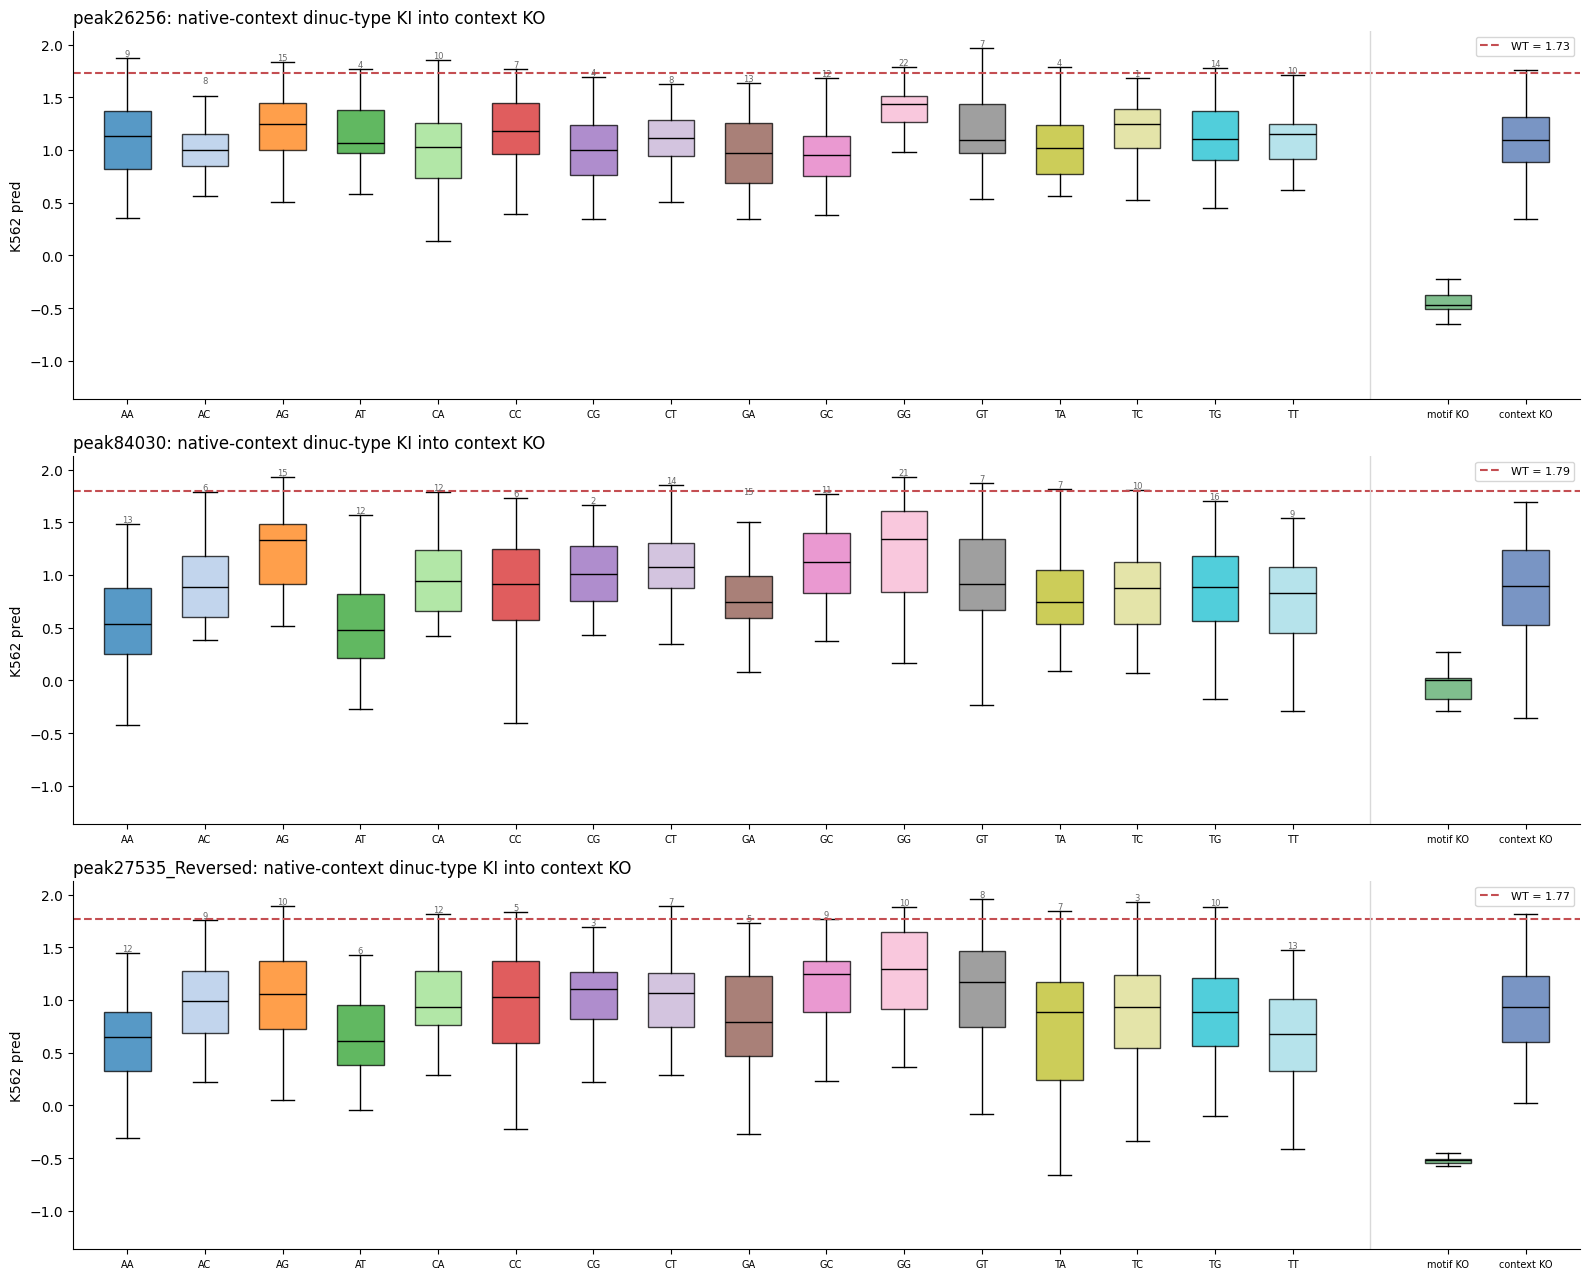

In [44]:
# Fixed x-layout so the 16 dinucs sit at the SAME column (1..16, AA..TT) in every seq and every experiment;
# reference boxes go right of a divider. box color = dinuc identity; shared YLIM = same pred scale everywhere.
# Number above each box = how many times that dinuc occurs in the donor's context. Figures saved as 300-dpi PNG.
dcol = dict(zip(dinucs, plt.cm.tab20(np.linspace(0, 1, 16))))
DPOS = {d: i + 1 for i, d in enumerate(dinucs)}
OUT = Path("/grid/koo/home/pmantill/projects/SEAM_validate/context_feat/context_KO_rescue")

def plot_dinuc_ki(res, refs, extra_hline, title, save):
    # res: {donor: {ki, counts, wt, <ref keys>}};  refs: [(label, key, color)] -> boxes at x=18,19,...
    rp = 18 + np.arange(len(refs))
    fig, axes = plt.subplots(len(high), 1, figsize=(16, 4.3 * len(high)), squeeze=False, sharey=True)
    for ax, donor in zip(axes[:, 0], high):
        r = res[donor]
        present = [d for d in dinucs if d in r["ki"]]
        bp = ax.boxplot([r["ki"][d] for d in present], positions=[DPOS[d] for d in present],
                        widths=0.6, patch_artist=True, showfliers=False)
        for patch, d in zip(bp["boxes"], present):
            patch.set_facecolor(dcol[d]); patch.set_alpha(0.75)
        for d in present:
            ax.text(DPOS[d], np.max(r["ki"][d]), r["counts"][d], ha="center", va="bottom", fontsize=6, color="0.4")
        rb = ax.boxplot([r[k] for _, k, _ in refs], positions=rp, widths=0.6, patch_artist=True, showfliers=False)
        for patch, (_, _, c) in zip(rb["boxes"], refs):
            patch.set_facecolor(c); patch.set_alpha(0.75)
        for med in bp["medians"] + rb["medians"]:
            med.set_color("k")
        ax.axhline(r["wt"], color="#c44e52", ls="--", lw=1.5, label=f"WT = {r['wt']:.2f}")
        if extra_hline:
            ax.axhline(extra_hline[1], color="k", ls=":", lw=1.2, label=f"{extra_hline[0]} = {extra_hline[1]:.2f}")
        ax.axvline(17, color="0.85", lw=1)
        ax.set_xticks(list(range(1, 17)) + list(rp))
        ax.set_xticklabels(dinucs + [l for l, _, _ in refs], fontsize=7)
        ax.set_xlim(0.3, rp[-1] + 0.7); ax.set_ylim(YLIM)
        ax.set_ylabel("K562 pred"); ax.set_title(f"{all_names[donor]}: {title}", loc="left")
        ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    fig.savefig(OUT / save, dpi=300, bbox_inches="tight")

plot_dinuc_ki(main, [("motif KO", "motko", "#55a868"), ("context KO", "ctxko", "#4c72b0")],
              None, "native-context dinuc-type KI into context KO", "dinuc_ki_contextKO.png")


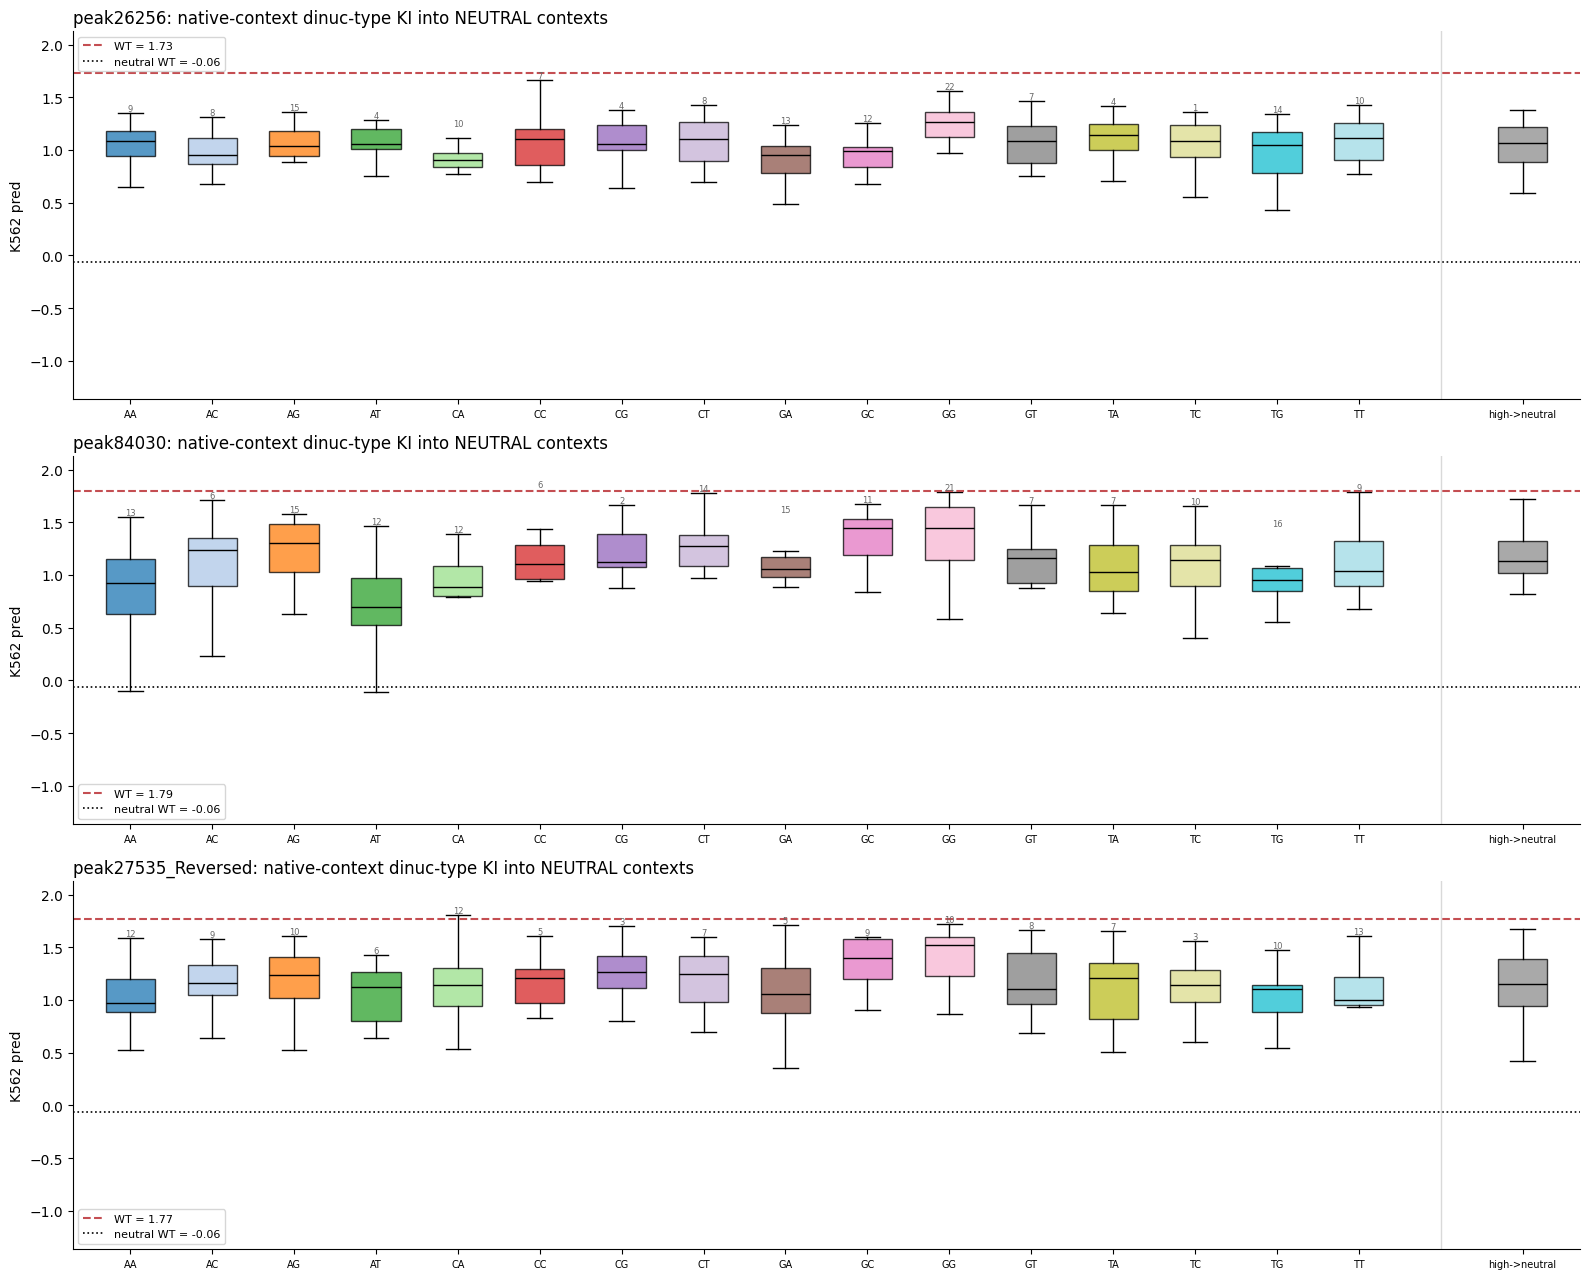

In [45]:
# NEUTRAL-CONTEXT variant: high motifs in motif-free neutral contexts, then native-context dinuc-type KI.
# baseline box "high->neutral" == swap_experiment's swap[donor][neutral targets] (motifs only).
plot_dinuc_ki(neut, [("high->neutral", "base", "#8c8c8c")], ("neutral WT", neut_wt),
              "native-context dinuc-type KI into NEUTRAL contexts", "dinuc_ki_neutral.png")


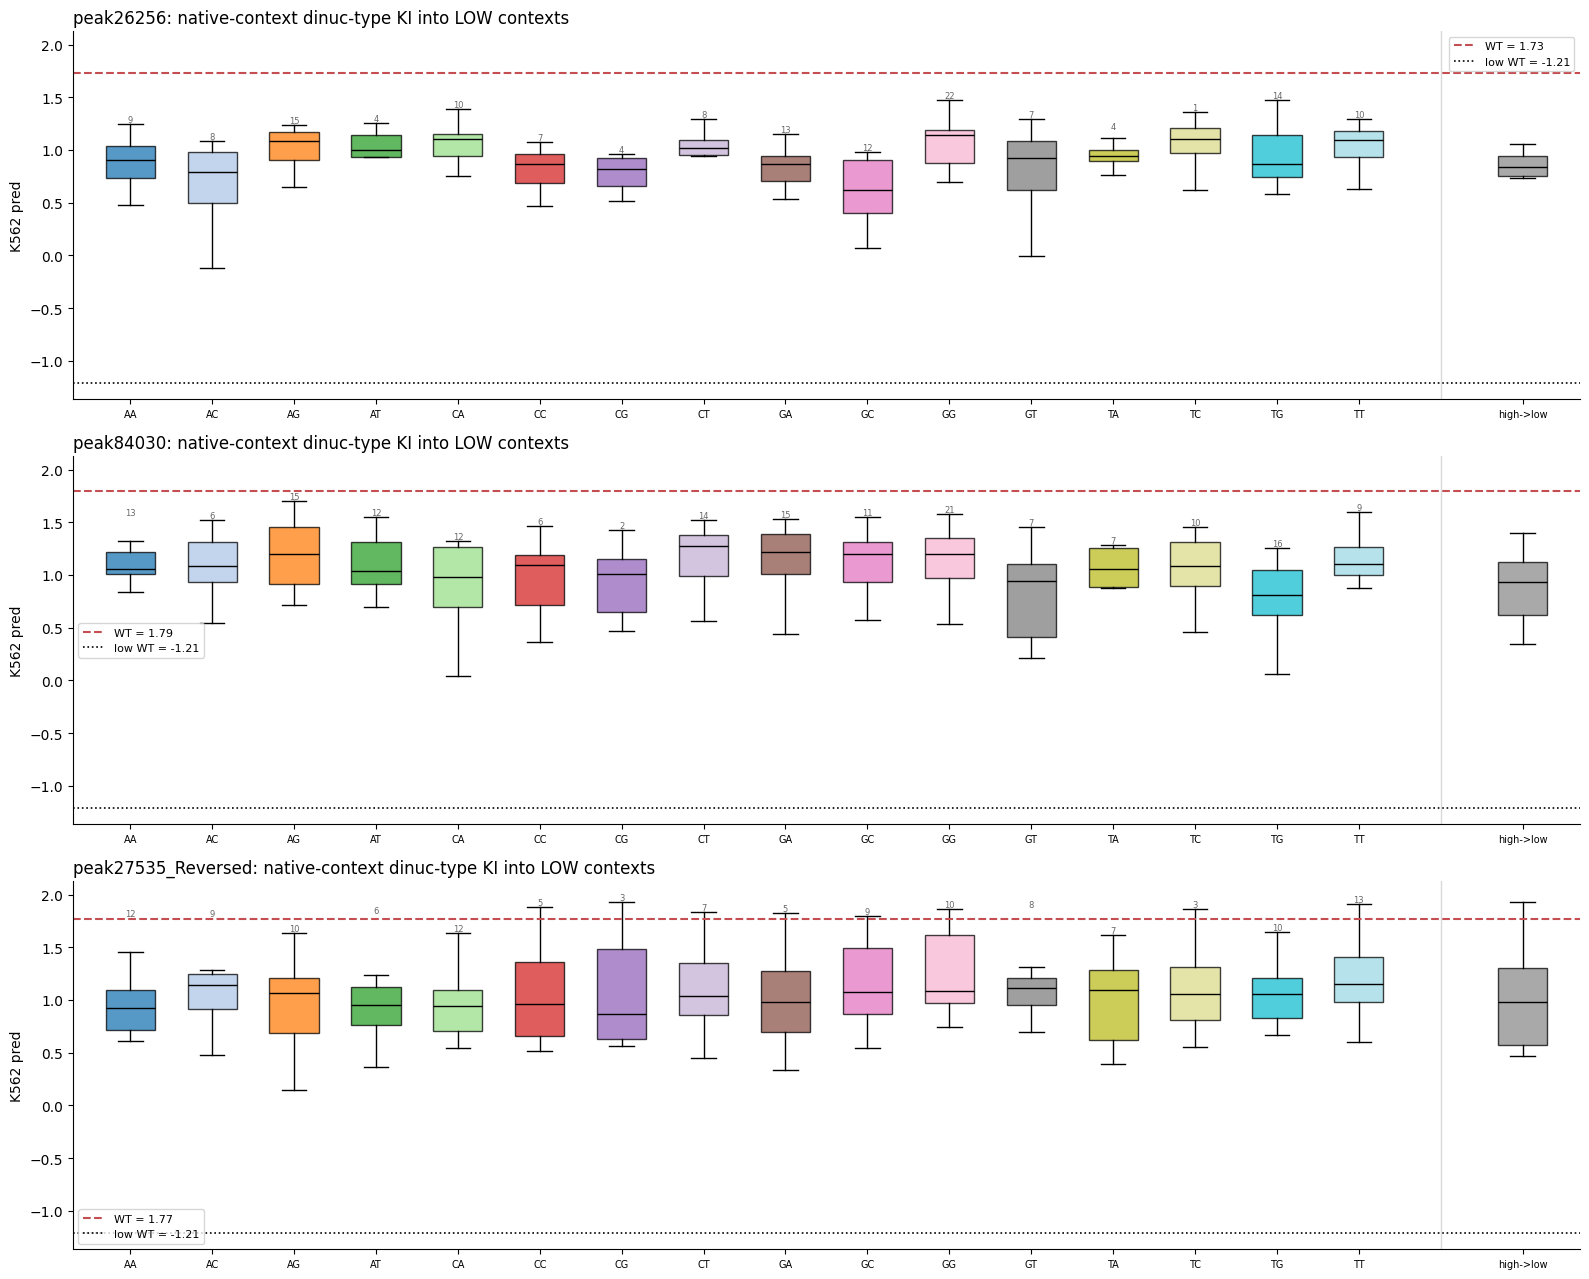

In [46]:
# LOW-CONTEXT variant: high motifs in motif-free low rep-seq contexts, then native-context dinuc-type KI.
# baseline box "high->low" == swap_experiment's swap[donor][low targets] (motifs only).
plot_dinuc_ki(lowc, [("high->low", "base", "#8c8c8c")], ("low WT", low_wt),
              "native-context dinuc-type KI into LOW contexts", "dinuc_ki_low.png")


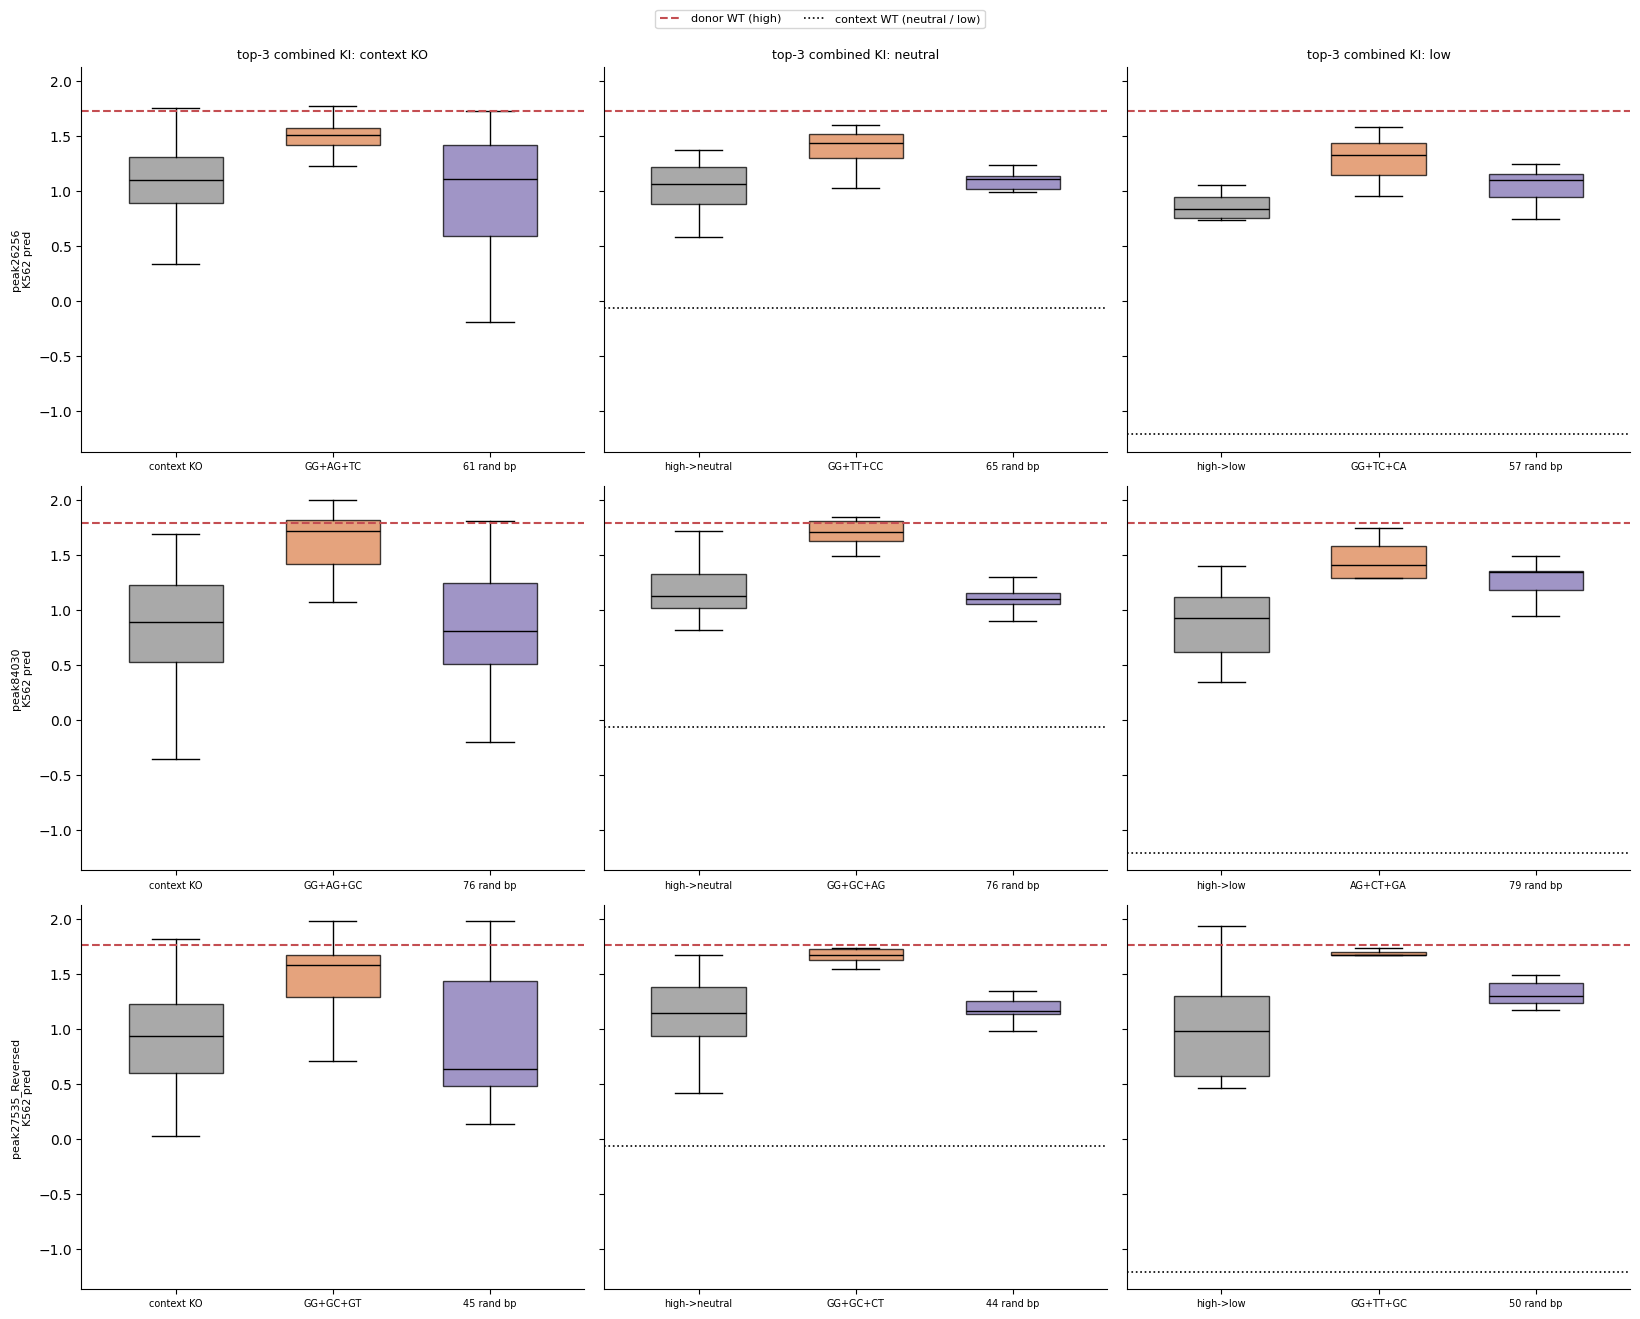

In [47]:
# TOP-3 COMBINED KI vs a random-position control. For each plot (donor x experiment): take the 3 dinuc types
# that individually rescued most, KI all their native occurrences together (orange), and as a control KI the
# SAME number of bases at random context positions (purple). Columns = context KO / neutral / low, rows = high seq.
# context KO = N KI reps (box); neutral/low = per-context means (box). Saved as 300-dpi PNG.
def donor_shuf(donor):
    return dinucleotide_shuffle(one_hot_encode(seq_str[donor]).float().unsqueeze(0), n=N, random_state=0)[0]

def scaffold(donor, bg):                                                # donor motifs into bg -> (dwt, motif mask, base)
    dwt = one_hot_encode(seq_str[donor]).float()
    m_any = np.zeros(230, bool)
    for s, e in mot[donor]:
        m_any[s:e] = True
    base = bg.clone(); base[:, :, m_any] = dwt[:, m_any]
    return dwt, m_any, base

def ki_mask(dwt, base, mask, reps):                                     # restore donor WT at a fixed set of positions
    agg = (lambda p: p.reshape(-1, reps).mean(1)) if reps else (lambda p: p)
    x = base.clone(); x[:, :, mask] = dwt[:, mask]
    return agg(score(x))

def rand_ki(dwt, base, m_any, k, reps, seed=0):                        # restore donor WT at k random context positions (fresh draw per row)
    agg = (lambda p: p.reshape(-1, reps).mean(1)) if reps else (lambda p: p)
    ctx_pos = np.array([p for p in range(ADAPTER, ADAPTER + 200) if not m_any[p]])
    rng = np.random.default_rng(seed)
    x = base.clone()
    for row in range(x.shape[0]):
        sel = torch.as_tensor(rng.choice(ctx_pos, size=k, replace=False))
        x[row][:, sel] = dwt[:, sel]
    return agg(score(x))

# per experiment: (col title, results, baseline key, bg provider, reps, dotted-line ref, baseline box label)
exps = [("context KO", main, "ctxko", donor_shuf, None, None, "context KO"),
        ("neutral",    neut, "base",  lambda d: neut_bg, N, ("neutral WT", neut_wt), "high->neutral"),
        ("low",        lowc, "base",  lambda d: low_bg,  N, ("low WT", low_wt), "high->low")]

fig, axes = plt.subplots(len(high), len(exps), figsize=(5.5 * len(exps), 4.3 * len(high)), squeeze=False, sharey=True)
for col, (name, res, bkey, bgf, reps, hline, blabel) in enumerate(exps):
    for row, donor in enumerate(high):
        ax = axes[row][col]
        r = res[donor]
        top3 = sorted(r["ki"], key=lambda d: -r["ki"][d].mean())[:3]
        dwt, m_any, base = scaffold(donor, bgf(donor))
        dseq = seq_str[donor]
        mask = np.zeros(230, bool)                                      # native positions of the top-3 dinuc types
        for i in range(ADAPTER, ADAPTER + 200 - 1):
            if dseq[i:i + 2] in set(top3) and not m_any[i:i + 2].any():
                mask[i:i + 2] = True
        k = int(mask.sum())
        data = [r[bkey], ki_mask(dwt, base, mask, reps), rand_ki(dwt, base, m_any, k, reps)]
        bp = ax.boxplot(data, positions=[1, 2, 3], widths=0.6, patch_artist=True, showfliers=False)
        for patch, c in zip(bp["boxes"], ["#8c8c8c", "#dd8452", "#8172b3"]):
            patch.set_facecolor(c); patch.set_alpha(0.75)
        for med in bp["medians"]:
            med.set_color("k")
        ax.axhline(r["wt"], color="#c44e52", ls="--", lw=1.5)
        if hline:
            ax.axhline(hline[1], color="k", ls=":", lw=1.2)
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([blabel, "+".join(top3), f"{k} rand bp"], fontsize=7)
        ax.set_xlim(0.4, 3.6); ax.set_ylim(YLIM); ax.spines[["top", "right"]].set_visible(False)
        if col == 0:
            ax.set_ylabel(f"{all_names[donor]}\nK562 pred", fontsize=8)
        if row == 0:
            ax.set_title(f"top-3 combined KI: {name}", fontsize=9)
plt.tight_layout()
fig.legend(handles=[plt.Line2D([], [], color="#c44e52", ls="--", lw=1.5),
                    plt.Line2D([], [], color="k", ls=":", lw=1.2)],
           labels=["donor WT (high)", "context WT (neutral / low)"],
           loc="lower center", ncol=2, fontsize=8, bbox_to_anchor=(0.5, 1.0))
fig.savefig(OUT / "dinuc_ki_top3_combined.png", dpi=300, bbox_inches="tight")
